In [1]:
from superfv import HydroSolver, BC, ics, MUSCL_SlopeLimiter, RiemannSolver, HydroSolverOutput, SnapshotMode
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
import os
import shutil

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams["font.size"] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['41.43GB', '42.41GB']


In [3]:
base_directory = "/scratch/gpfs/jp7427/FVvsSD/gresho/"

In [4]:
def run_superfv_sim(name, p, N, v0=5.0, M_max=0.1, **kwargs):
    path = base_directory + f"FV_{name}_{v0=}_{M_max=}_{N=}_{p=}"

    try:
        out = HydroSolverOutput(path)
        print(f"Loaded output from '{path}'")
        return out
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    if os.path.exists(path):
        print(f"Removing bad output at '{path}'")
        shutil.rmtree(path)
    

    sim = HydroSolver(
        ic=partial(ics.gresho_vortex, gamma=5 / 3, v0=v0, M_max=M_max),
        gamma=5 / 3,
        rho_min=1e-10,
        P_min=1e-10,
        nx=N,
        ny=N,
        p=p,
        cupy=True,
        output_path=path,
        **kwargs,
    )
    sim.run(1.0)
    return sim

In [10]:
def run_spd_sim(name, p, N, v0=5.0, M_max=0.1, **kwargs):
    path = base_directory + f"SD_{name}_{v0=}_{M_max=}_{N=}_{p=}"
    
    sim = SPD_Simulator(
        p=p,
        N=(N, N),
        init_fct=ic.gresho_vortex(gamma=5/3, v0=v0, M_max=M_max),
        gamma=5/3,
        cfl_coeff=0.4,
        use_cupy=True,
        time_integrator="rk3",
        scheme="SD",
        FB=False,
        riemann_solver_sd="hllc",  # MUSCL fallback flux
        folder=path,
        **kwargs,
    )

    try:
        sim.load_output()
        print(f"Loaded output from '{path}'")
        return sim
    except Exception as e:
        print(f"Failed to load output from '{path}' with: {e}")
        pass

    sim.perform_time_evolution(1.0)
    sim.output()
    return sim
        

In [38]:
def compute_M(rho, vx, vy, P, x, y, gamma, v0):
    xc = x - 0.5
    yc = y - 0.5
    r = np.sqrt(xc**2 + yc**2)

    v_phi = vx * (-yc / r) + vy * (xc / r)

    cs2 = gamma * P / rho
    cs = np.sqrt(np.maximum(cs2, 0.0))

    M = np.abs(v_phi) / cs

    return M

def compute_M_from_fv(sim, v0):
    idx = sim.params.variable_index_map
    mesh = sim.mesh
    w = sim.snapshot_history[-1].w

    x, y, _ = mesh.Centers
    x = cp.asnumpy(x)
    y = cp.asnumpy(y)
    rho = w[idx("rho")]
    vx = w[idx("vx")] - v0
    vy = w[idx("vy")]
    P = w[idx("P")]

    return compute_M(rho, vx, vy, P, x, y, sim.params.hydro.gamma, v0)

def compute_M_from_sd(sim, v0):
    x = sim.regular_centers()[0]
    y = sim.regular_centers()[1]
    w = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))

    rho = w[0]
    vx  = w[1] - v0
    vy  = w[2]
    P   = w[4]

    return compute_M(rho, vx, vy, P, x, y, sim.gamma, v0)

In [7]:
NDOF = 96
p = 3
N = NDOF // (p + 1)

In [22]:
s1 = run_superfv_sim("p=3", p, NDOF, v0=5.0, M_max=0.1)

Loaded output from '/scratch/gpfs/jp7427/FVvsSD/gresho/FV__v0=5.0_M_max=0.1_N=96_p=3'


In [11]:
s2 = run_spd_sim("p=3", p, N, v0=5.0, M_max=0.1)

Failed to load output from '/scratch/gpfs/jp7427/FVvsSD/gresho/SD__v0=5.0_M_max=0.1_N=24_p=3' with: /scratch/gpfs/jp7427/FVvsSD/gresho/SD__v0=5.0_M_max=0.1_N=24_p=3/outputs.out not found.
t=1.0, steps taken 6327, time taken 89.189, bzcps = 0.001


(96, 96)


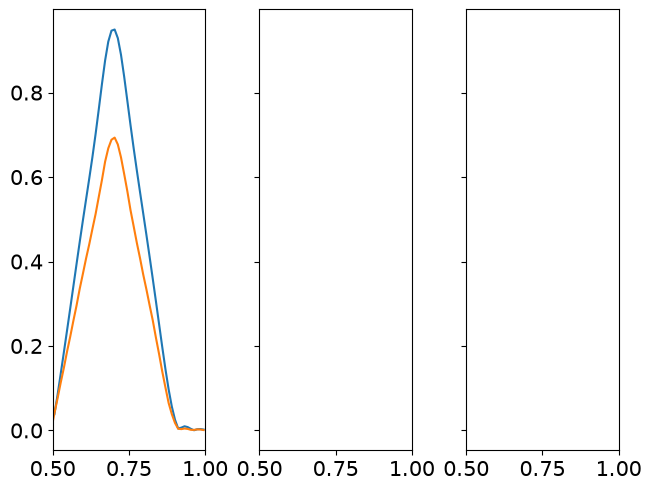

In [42]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, constrained_layout=True)
axs[0].set_xlim(0.5, 1)

x = cp.asnumpy(s1.mesh.centers[0])

axs[0].plot(x, compute_M_from_fv(s1, 5.0)[:, :, 0].T[NDOF//2, :] / 0.1)
axs[0].plot(x, compute_M_from_sd(s2, 5.0)[NDOF//2, :] / 0.1)